#Pregunta principal
# ✅ ¿Existe una correlacion estadisticamente significativa entre el gasto neto en transferencias y la posicion final en la tabla de la Premier League?

*¿Existe una relación entre el gasto neto en transferencias (inversión menos ingresos) y el rendimiento deportivo (puntos obtenidos, posición final) en la Premier League 2022/23? ¿Qué clubes fueron más eficientes en transformar dinero en puntos?*

### Subpreguntas q se pueden agregar:

- ¿El gasto neto explica diferencias en posición final o hay outliers que desafían esa relación (Chelsea gastó mucho y rindió mal; Brighton gastó poco y rindió bien)?

- ¿Cómo se compara la eficiencia de gasto entre clubes que gastaron mucho vs clubes con gasto neto negativo (vendieron más de lo que compraron)?

- ¿Existe un nivel de gasto neto a partir del cual los puntos adicionales se obtienen con rendimientos decrecientes? (optimización)

SE PUEDE EMPEZAR USANDO EL DATASET "GASTOS EN TRANSF POR LIGA" Y MOSTRAR QUE LA PREMIER ES LA QUE MAS MUEVE O MOVIO EN ESA TEMPO COMO PARA DAR UNA INTRO DE PORQ USAMOS ESA

In [1]:
# Celda 1: Imports y configuración
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import re

# Para mostrar mejor los gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Celda 2: Cargar datasets directamente desde el entorno de Colab

# Archivo de posiciones (en formato .xlsx)
posiciones = pd.read_csv('/content/premier posiciones 22-23 - premier posiciones 22-23.xlsx (1).csv')

# Archivo de transferencias (en formato .csv)
transfers = pd.read_csv('/content/transferencias_2022_2022 (1).csv')

# Mostrar primeras filas
print("Posiciones:")
display(posiciones.head())
print("Transferencias:")
display(transfers.head(20))

Posiciones:


,#,Club,PJ,PG,PE,PP,GF,GC,DG,Pts
0,1,Manchester City,38,28,5,5,94,33,61,89
1,2,Arsenal FC,38,26,6,6,88,43,45,84
2,3,Manchester United,38,23,6,9,58,43,15,75
3,4,Newcastle United,38,19,14,5,68,33,35,71
4,5,Liverpool FC,38,19,10,9,75,47,28,67


Transferencias:


,club_name,player_name,age,position,club_involved_name,fee,transfer_movement,transfer_period,fee_cleaned,league_name,year,season,country
0,Arsenal FC,Gabriel Jesus,25.0,Centre-Forward,Man City,€52.20m,in,Summer,52.20,Premier League,2022,2022/2023,England
1,Arsenal FC,Oleksandr Zinchenko,25.0,Left-Back,Man City,€35.00m,in,Summer,35.00,Premier League,2022,2022/2023,England
2,Arsenal FC,Fábio Vieira,22.0,Attacking Midfield,FC Porto,€35.00m,in,Summer,35.00,Premier League,2022,2022/2023,England
3,Arsenal FC,Matt Turner,28.0,Goalkeeper,New England,€6.36m,in,Summer,6.36,Premier League,2022,2022/2023,England
4,Arsenal FC,Marquinhos,19.0,Right Winger,São Paulo,€3.50m,in,Summer,3.50,Premier League,2022,2022/2023,England
5,Arsenal FC,Konstantinos Mavropanos,24.0,Centre-Back,VfB Stuttgart,"End of loanJun 30, 2022",in,Summer,NaN,Premier League,2022,2022/2023,England
6,Arsenal FC,Auston Trusty,23.0,Centre-Back,Colorado,"End of loanJul 14, 2022",in,Summer,NaN,Premier League,2022,2022/2023,England
7,Arsenal FC,Ainsley Maitland-Niles,25.0,Right Midfield,Southampton,"End of loanMay 31, 2023",in,Summer,NaN,Premier League,2022,2022/2023,England
8,Arsenal FC,Mattéo Guendouzi,23.0,Central Midfield,Marseille,"End of loanJun 30, 2022",in,Summer,NaN,Premier League,2022,2022/2023,England
9,Arsenal FC,William Saliba,21.0,Centre-Back,Marseille,"End of loanJun 30, 2022",in,Summer,NaN,Premier League,2022,2022/2023,England


In [3]:
# Celda 3: Exploración inicial
print("Dimensiones posiciones:", posiciones.shape)
print("Nulos posiciones:\n", posiciones.isnull().sum())
print("\nDimensiones transfers:", transfers.shape)
print("Nulos transfers:\n", transfers.isnull().sum())
print("\nEstadísticas posiciones:")
display(posiciones.describe())

Dimensiones posiciones: (20, 10)
Nulos posiciones:
 #       0
Club    0
PJ      0
PG      0
PE      0
PP      0
GF      0
GC      0
DG      0
Pts     0
dtype: int64

Dimensiones transfers: (700, 13)
Nulos transfers:
 club_name               0
player_name             0
age                     0
position                0
club_involved_name      0
fee                     0
transfer_movement       0
transfer_period         0
fee_cleaned           399
league_name             0
year                    0
season                  0
country                 0
dtype: int64

Estadísticas posiciones:


,#,PJ,PG,PE,PP,GF,GC,DG,Pts
count,20.00000,20.0,20.000000,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,10.50000,38.0,14.650000,8.70000,14.650000,54.200000,54.200000,0.000000,52.650000
std,5.91608,0.0,6.310184,2.81163,5.993637,18.429382,12.775799,27.877552,18.189861
min,1.00000,38.0,6.000000,5.00000,5.000000,31.000000,33.000000,-37.000000,25.000000
25%,5.75000,38.0,10.500000,6.75000,9.000000,38.000000,46.000000,-24.000000,38.750000
50%,10.50000,38.0,13.000000,7.50000,15.500000,51.000000,53.000000,-3.500000,48.500000
75%,15.25000,38.0,18.250000,11.00000,19.250000,68.500000,64.250000,16.000000,63.250000
max,20.00000,38.0,28.000000,14.00000,25.000000,94.000000,78.000000,61.000000,89.000000


Notamos que hay 399 valores nulos en la tabla de transferencias que vienen de la columna fee_cleaned (tarifa limpia). esto se debe a que son casos en los que son "loan transfer" o casos donde llegan porque se les finalizo el contrato

abajo lo q se hizo es en fee_cleaned los valores que hayan estado vacios asignarle 0. y crear la columna valor_real para pasar ese fee_cleaned a millones

aca abajo posibles cosas a hacer:
- renombrar la columnas (ponerla en español)
- manejar los casos que en fee es "?" 0 "-" (mejor poner 0 o NaN)
- en vez de crear columna valor_real, dejar solo la de fee_cleaned, ya q de esa misma despues se puede agarrar ese valor y mulitiplicarlo por un millon direcatmente, sin tener q crear una columna extra

In [4]:
# Celda 4: Limpieza de transferencias - extraer fee numérico

#al final no se uso esta funcion
''' def extract_fee(fee_str):
    if pd.isna(fee_str):
        return 0.0
    fee_str = str(fee_str).lower().strip()

    # Manejar Loan fee: €x
    if 'loan fee:' in fee_str:
        match = re.search(r'[\d\.]+', fee_str)
        return float(match.group()) if match else 0.0

    # Manejar free transfer, end of loan, etc.
    if 'free' in fee_str or 'end of loan' in fee_str or fee_str in ['0', '?']:
        return 0.0

    # Extraer número
    match = re.search(r'[\d\.]+', fee_str)
    if match:
        val = float(match.group())
        if 'th' in fee_str or 'k' in fee_str:
            val = val / 1000.0   # miles → millones
        return val
    return 0.0 '''


# NUEVA COLUMNA: valor_real
# Si fee_cleaned está vacío/NaN → 0, si no → *1.000.000
transfers['valor_real'] = transfers['fee_cleaned'].apply(
    lambda x: 0 if pd.isna(x) or x == '' else x * 1_000_000
)

# opcional: dejarlo como entero para no tener .0
transfers['valor_real'] = transfers['valor_real'].astype('int64')
transfers['fee_cleaned'] = transfers['fee_cleaned'].fillna(0)

print("Fees extraídos. Ejemplo:")
filtrado = transfers[transfers['club_name'] == 'AFC Bournemouth']
display(filtrado[['club_name', 'transfer_movement', 'fee', 'fee_cleaned', 'valor_real']])

Fees extraídos. Ejemplo:


<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_572/1141003188.py:11: SyntaxWarning: invalid escape sequence '\d'
  match = re.search(r'[\d\.]+', fee_str)


,club_name,transfer_movement,fee,fee_cleaned,valor_real
60,AFC Bournemouth,in,€15.00m,15.00,15000000
61,AFC Bournemouth,in,€11.90m,11.90,11900000
62,AFC Bournemouth,in,free transfer,0.00,0
63,AFC Bournemouth,in,free transfer,0.00,0
64,AFC Bournemouth,in,free transfer,0.00,0
65,AFC Bournemouth,in,loan transfer,0.00,0
66,AFC Bournemouth,in,"End of loanMay 31, 2023",0.00,0
67,AFC Bournemouth,in,"End of loanMay 31, 2023",0.00,0
68,AFC Bournemouth,out,free transfer,0.00,0
69,AFC Bournemouth,out,?,0.00,0


abajo: Agrupamos y creamos tabla con gasto, ingreeso y gasto neto de cada club

In [5]:
# Celda 5: Agrupar por club y movimiento
gastos = transfers[transfers['transfer_movement'] == 'in'].groupby('club_name')['valor_real'].sum().reset_index()
gastos.columns = ['club', 'gasto_total_in_M']
ingresos = transfers[transfers['transfer_movement'] == 'out'].groupby('club_name')['valor_real'].sum().reset_index()
ingresos.columns = ['club', 'ingreso_total_out_M']

# Convertir a millones de euros para consistencia
gastos['gasto_total_in_M'] = gastos['gasto_total_in_M'] / 1_000_000
ingresos['ingreso_total_out_M'] = ingresos['ingreso_total_out_M'] / 1_000_000

# Unir
finanzas = pd.merge(gastos, ingresos, on='club', how='outer').fillna(0)
finanzas['gasto_neto_M'] = finanzas['gasto_total_in_M'] - finanzas['ingreso_total_out_M']
# Redondear
finanzas = finanzas.round(2)
print("Resumen financiero por club:")
display(finanzas.sort_values('gasto_neto_M', ascending=False))

Resumen financiero por club:


,club,gasto_total_in_M,ingreso_total_out_M,gasto_neto_M
5,Chelsea FC,611.49,70.10,541.39
13,Manchester United,243.29,11.50,231.79
14,Newcastle United,185.35,2.31,183.04
15,Nottingham Forest,184.25,7.00,177.25
18,West Ham United,194.00,21.55,172.45
1,Arsenal FC,192.36,23.80,168.56
17,Tottenham Hotspur,177.90,38.75,139.15
16,Southampton FC,136.65,0.00,136.65
19,Wolverhampton Wanderers,175.11,60.37,114.74
0,AFC Bournemouth,83.10,0.00,83.10


## Costes totales de transferencia entrantes frente a salientes por club


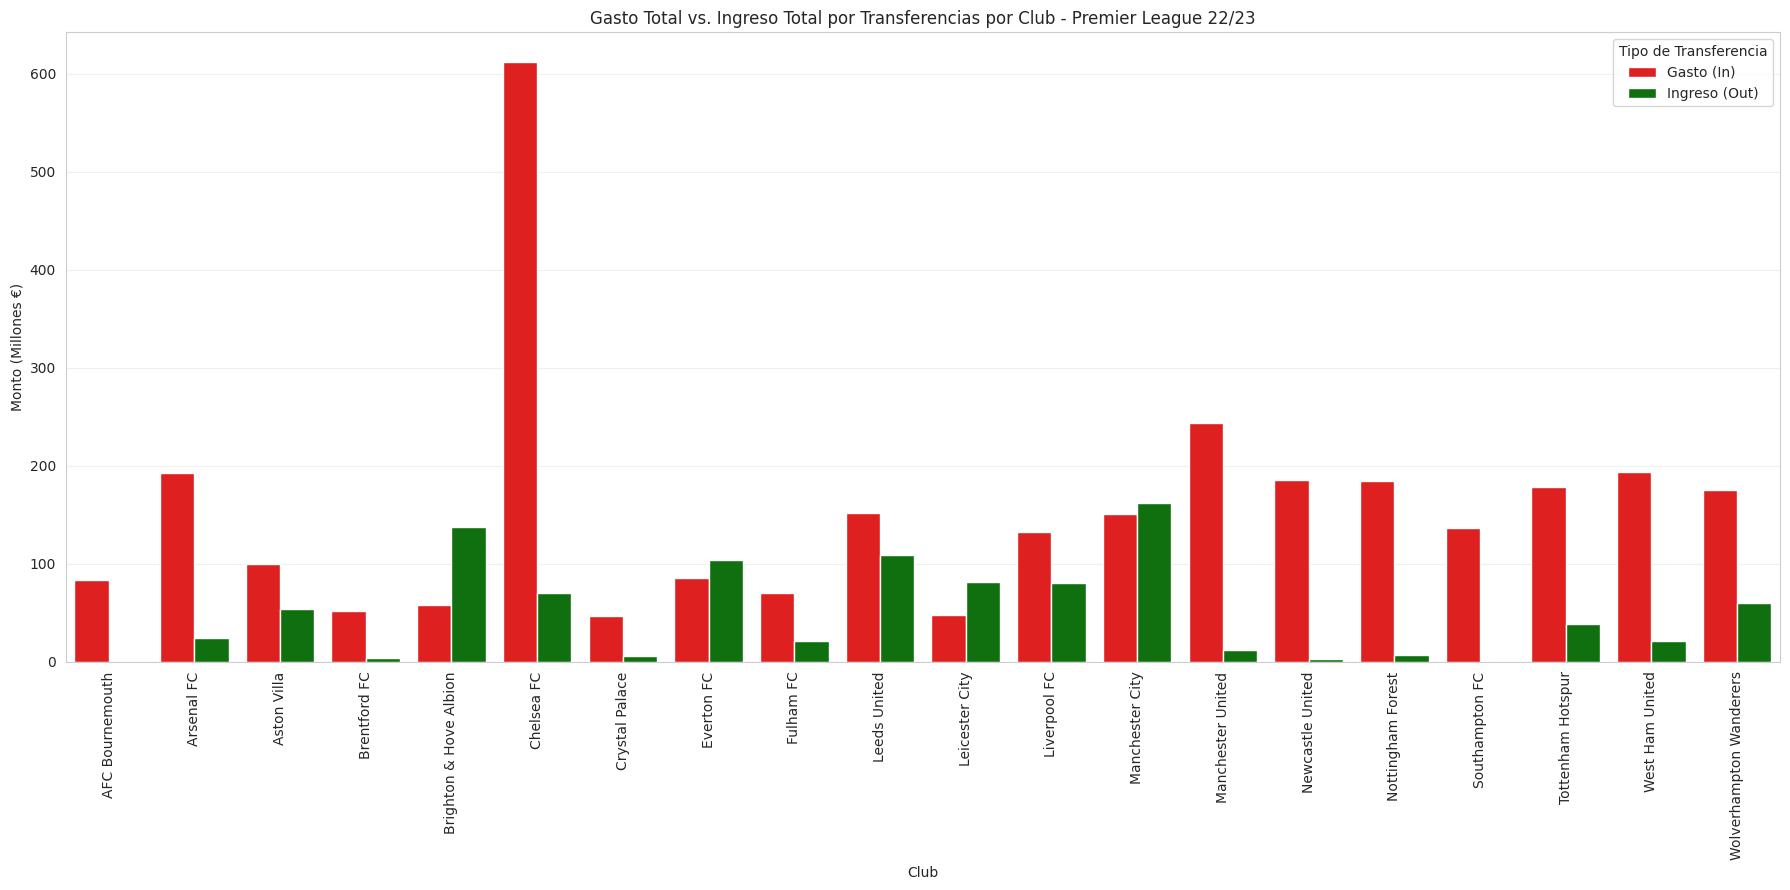

In [6]:

# Desintegra el DataFrame de finanzas para facilitar la representación gráfica con seaborn.
finanzas_melted = finanzas.melt(id_vars='club',
                                value_vars=['gasto_total_in_M', 'ingreso_total_out_M'],
                                var_name='Transfer_Type',
                                value_name='Amount_M_Euro')

# Cambiamos las etiquetas del DataFrame para que aparezcan correctamente en la leyenda automática
finanzas_melted['Transfer_Type'] = finanzas_melted['Transfer_Type'].map({
    'gasto_total_in_M': 'Gasto (In)',
    'ingreso_total_out_M': 'Ingreso (Out)'
})

plt.figure(figsize=(18, 9))

# Definimos los nuevos colores en la paleta usando los nuevos nombres
sns.barplot(
    x='club',
    y='Amount_M_Euro',
    hue='Transfer_Type',
    data=finanzas_melted,
    palette={'Gasto (In)': 'red', 'Ingreso (Out)': 'green'}
)

plt.xlabel('Club')
plt.ylabel('Monto (Millones €)')
plt.title('Gasto Total vs. Ingreso Total por Transferencias por Club - Premier League 22/23')
plt.xticks(rotation=90)

# Dejamos que plt.legend use las etiquetas reales del DataFrame para no romper los colores
plt.legend(title='Tipo de Transferencia')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Este gráfico de barras agrupadas muestra claramente el monto total que cada club gastó en nuevos jugadores y el monto total que recibió por la venta de jugadores en millones de euros

In [7]:
# Unir con tabla de posiciones
# Normalizar nombres de clubes (tu tabla posiciones usa 'Arsenal FC' vs 'Arsenal FC'? Está igual)
# Verificar coincidencias
posiciones['club'] = posiciones['Club']  # renombrar
union = pd.merge(posiciones, finanzas, on='club', how='left').fillna(0)
# Ver equipos sin datos de transferencias (puede pasar si no hicieron movimientos con fee)
print("Equipos sin datos de transferencias (gasto neto 0):")
print(union[union['gasto_neto_M'] == 0][['club', 'Pts', 'gasto_neto_M']])

Equipos sin datos de transferencias (gasto neto 0):
Empty DataFrame
Columns: [club, Pts, gasto_neto_M]
Index: []


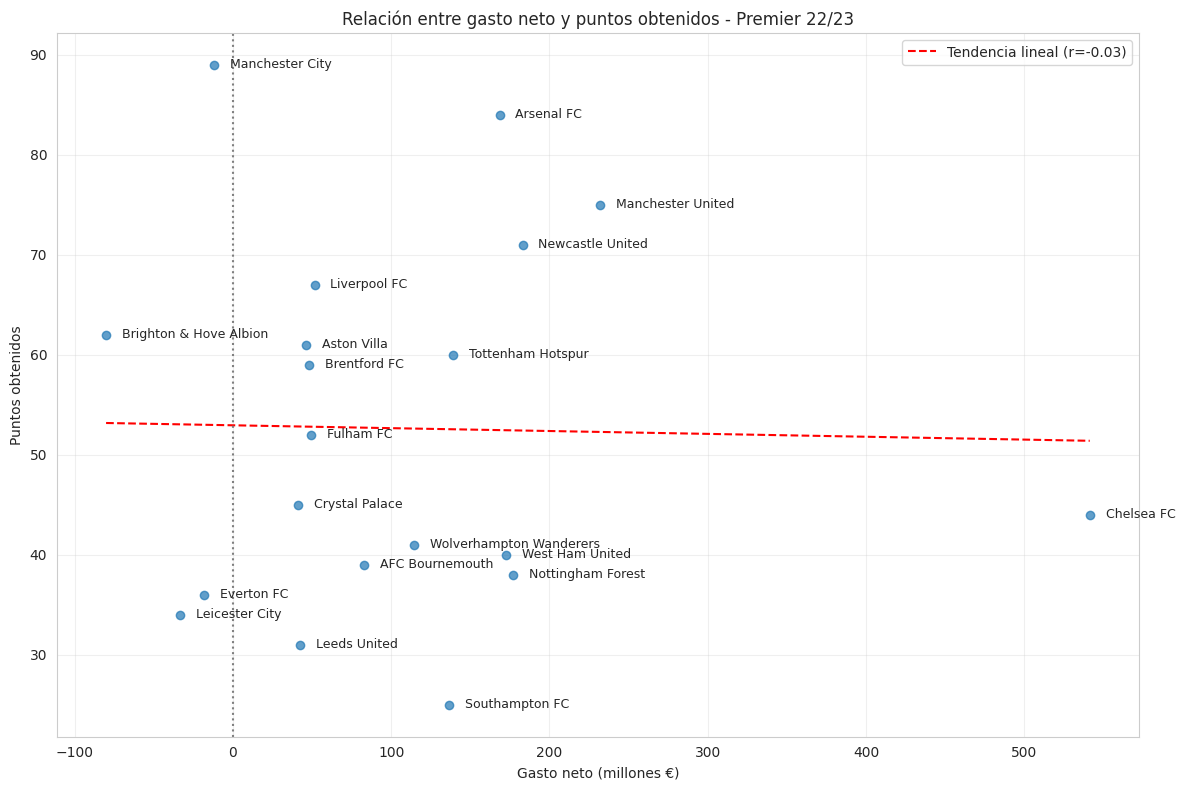

In [8]:
# Celda 7: Gráfico 1 - Dispersión gasto neto vs posición (invertir eje Y)
plt.figure(figsize=(12,8)) # Aumentar el tamaño para el texto

union['posicion'] = union['#']  # asumiendo que la columna se llama '#'


union['puntos']=union['Pts']

#gastoxpuntos=union['gasto_neto_M'], union['puntos']
#display(gastoxpuntos)

# Crear el scatter plot
plt.scatter(union['gasto_neto_M'], union['puntos'], alpha=0.7)

# Ajustar regresión lineal
z = np.polyfit(union['gasto_neto_M'], union['puntos'], 1)
p = np.poly1d(z)
plt.plot(sorted(union['gasto_neto_M']), p(sorted(union['gasto_neto_M'])), "r--", label=f"Tendencia lineal (r={np.corrcoef(union['gasto_neto_M'], union['posicion'])[0,1]:.2f})")

# Añadir etiquetas de texto para cada punto (nombre del club)
for i, row in union.iterrows():
    plt.text(row['gasto_neto_M'] + 10, row['puntos'], row['club'], fontsize=9, ha='left', va='center')

plt.axvline(x=0, linestyle='dotted', color='grey')
plt.xlabel('Gasto neto (millones €)')
plt.ylabel('Puntos obtenidos')
plt.title('Relación entre gasto neto y puntos obtenidos - Premier 22/23')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafico1_dispersion_gasto_vs_posicion_con_nombres.png') # Guardar con un nuevo nombre
plt.show()

**aca con este podriamos dar la respuesta a la pregunta central**

como valor de r=-0,03  -> Correlacion prácticamente nula (casi 0)

El coeficiente de correlación de -0.03 indica una relación lineal prácticamente inexistente entre el gasto neto y los puntos obtenidos, lo que sugiere que, para la temporada 2022/23, el rendimiento no puede predecirse a partir de la inversión neta en transferencias.”

r² = 0.0009 → solo el 0.09% de la variación en puntos se explica por el gasto neto. El 99.91% restante depende de otros factores.

## Conclusiones del análisis de correlación y el gráfico:

1.  **Correlación Débil a Nula:** El coeficiente de correlación de Pearson de **-0.03** indica una relación lineal muy débil y prácticamente insignificante entre el gasto neto en transferencias y la posición final en la tabla. Esto significa que el gasto neto por sí solo no es un predictor fuerte de la posición en la Premier League 2022/23.

2.  **Tendencia General Muy Suave:** Aunque la línea de tendencia lineal muestra una ligera inclinación hacia arriba (recordando que el eje Y está invertido, por lo que una posición más baja en el gráfico significa un mejor rendimiento), esta tendencia es extremadamente tenue y no sugiere un patrón claro donde un mayor gasto garantice una mejor posición.

3.  **Presencia de Outliers y Casos Particulares:**
    *   **Chelsea:** Destaca por un gasto neto muy alto, pero su posición final fue significativamente más baja de lo que la línea de tendencia podría sugerir, lo que lo convierte en un `outlier` negativo en términos de eficiencia de gasto.
    *   **Brighton & Hove Albion:** Demuestra una gran eficiencia, logrando una buena posición con un gasto neto bajo o incluso negativo (indicando una venta neta de jugadores superior a las compras).
    *   **Newcastle United:** Muestra una buena combinación de inversión y rendimiento, obteniendo una posición alta con una inversión considerable, pero no exorbitante en comparación con los líderes de gasto.
    *   **Los 'Big Six' (o equipos tradicionalmente fuertes):** Muchos de ellos tienen gastos netos elevados, pero su rendimiento varía. Manchester City (campeón) y Arsenal (subcampeón) son ejemplos de altos gastos con éxito deportivo, pero esto no es universal.

4.  **Otros Factores en Juego:** La ausencia de una correlación fuerte sugiere que otros factores, como la gestión del equipo, la táctica, el desarrollo de jugadores jóvenes, la cohesión del equipo, la suerte con las lesiones y el rendimiento individual, juegan un papel mucho más importante en la determinación de la posición final que el simple volumen de gasto neto en transferencias.

En resumen, el gráfico y la correlación numérica sugieren que, si bien la inversión en fichajes puede ser una estrategia, **no es el único ni el principal determinante del éxito** en la Premier League. Hay clubes que logran mucho con poco y otros que gastan mucho con resultados decepcionantes.

OTRA CONCLUSION

No encontramos evidencia de una relación lineal entre el gasto neto en transferencias y los puntos obtenidos en la Premier League 22/23 (r = -0.03). Esto sugiere que, en una sola temporada, el rendimiento no puede explicarse únicamente por la diferencia entre compras y ventas. Factores como la masa salarial, la estabilidad del equipo o la gestión deportiva tienen un peso mayor.

### ✅ Grafico complemento de comparacion con la temporada anterior entre gasto neto y rendimiento. para apoyarse en no solo quedarse con una tempo


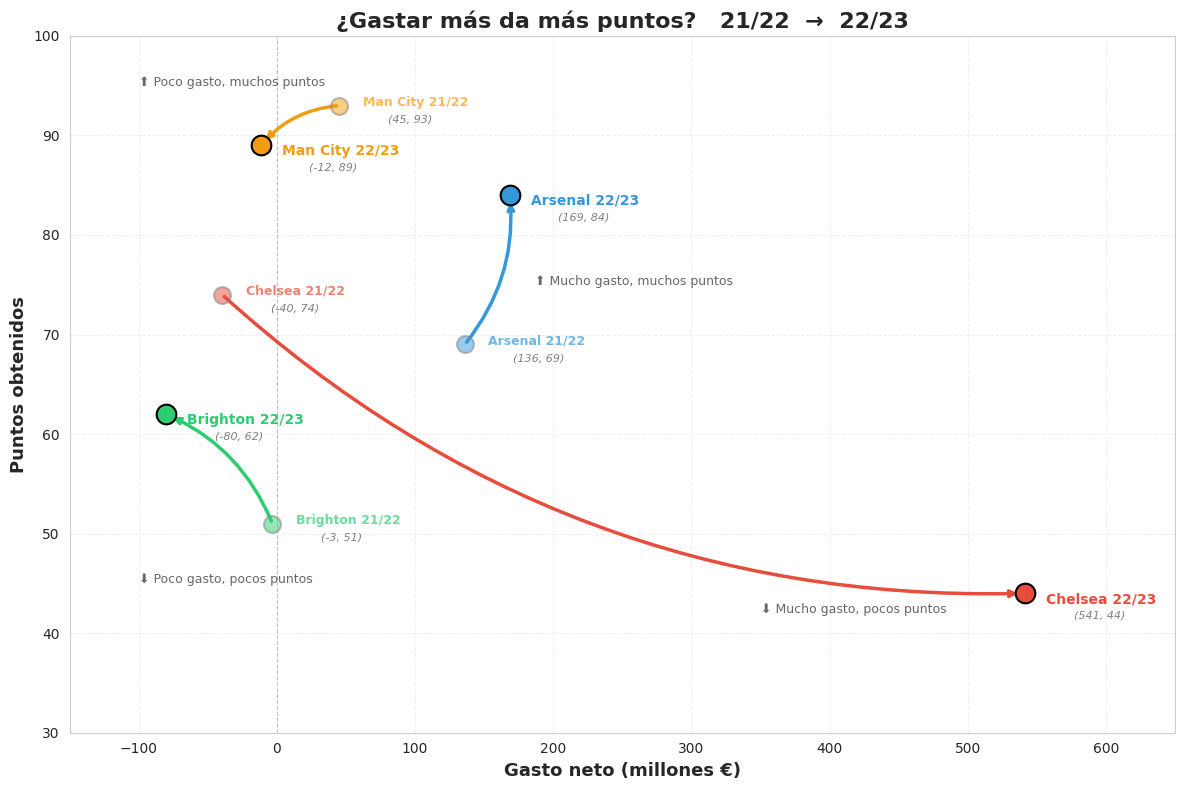

In [9]:
# Datos
equipos = ['Chelsea', 'Brighton', 'Arsenal', 'Man City']

# 21/22
gasto_21 = [-39.59, -3.22, 136, 45.10]
puntos_21 = [74, 51, 69, 93]

# 22/23
gasto_22 = [541.39, -80, 168.56, -11.70]
puntos_22 = [44, 62, 84, 89]

# Colores
colores = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

fig, ax = plt.subplots(figsize=(12, 8))

for i, eq in enumerate(equipos):
    # Flecha de 21/22 → 22/23
    ax.annotate('', xy=(gasto_22[i], puntos_22[i]),
                xytext=(gasto_21[i], puntos_21[i]),
                arrowprops=dict(arrowstyle='->', color=colores[i],
                                lw=2.5, connectionstyle='arc3,rad=0.2', shrinkB=5))

    # Punto 21/22 (más claro)
    ax.scatter(gasto_21[i], puntos_21[i], c=[colores[i]], s=150, zorder=5,
               edgecolors='gray', linewidth=1.5, alpha=0.5)
    ax.annotate(f'{eq} 21/22', (gasto_21[i], puntos_21[i]),
                xytext=(17, 0), textcoords="offset points",
                fontsize=9, color=colores[i], fontweight='bold', alpha=0.7)

    # Punto 22/23 (más intenso)
    ax.scatter(gasto_22[i], puntos_22[i], c=[colores[i]], s=200, zorder=5,
               edgecolors='black', linewidth=1.5)
    ax.annotate(f'{eq} 22/23', (gasto_22[i], puntos_22[i]),
                xytext=(15, -7), textcoords="offset points",
                fontsize=10, color=colores[i], fontweight='bold')

    # Valor al lado
    ax.annotate(f'({gasto_22[i]:.0f}, {puntos_22[i]})',
                (gasto_22[i], puntos_22[i]),
                xytext=(35, -18), textcoords="offset points",
                fontsize=8, color='gray', fontstyle='italic')
    ax.annotate(f'({gasto_21[i]:.0f}, {puntos_21[i]})',
                (gasto_21[i], puntos_21[i]),
                xytext=(35,-12), textcoords="offset points",
                fontsize=8, color='gray', fontstyle='italic')

ax.axhline(y=0, color='gray', linewidth=0.8, linestyle='--', alpha=0.4)
ax.axvline(x=0, color='gray', linewidth=0.8, linestyle='--', alpha=0.4)

ax.set_xlabel('Gasto neto (millones €)', fontsize=13, fontweight='bold')
ax.set_ylabel('Puntos obtenidos', fontsize=13, fontweight='bold')
ax.set_title('¿Gastar más da más puntos?   21/22  →  22/23',
             fontsize=16, fontweight='bold')

ax.set_xlim(-150, 650)
ax.set_ylim(30, 100)

# Texto en cuadrantes
ax.text(187, 75, '⬆ Mucho gasto, muchos puntos', fontsize=9, color='black', alpha=0.6)
ax.text(350, 42, '⬇ Mucho gasto, pocos puntos', fontsize=9, color='black', alpha=0.6)
ax.text(-100, 95, '⬆ Poco gasto, muchos puntos', fontsize=9, color='black', alpha=0.6)
ax.text(-100, 45, '⬇ Poco gasto, pocos puntos', fontsize=9, color='black', alpha=0.6)

ax.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

------------------------------------

In [10]:
# Calcular eficiencia neta y bruta. puntos obtenidos por millón neto gastado
#

union['eficiencia_neta'] = union['Pts'] / (union['gasto_neto_M'] + 1)
union['eficiencia_bruta'] = union['Pts'] / (union['gasto_total_in_M'] + 1)
# Ordenar por eficiencia neta
top_eficiencia = union.sort_values('eficiencia_neta', ascending=False)
print("Top 10 por eficiencia neta (puntos por millón neto gastado):")
display(top_eficiencia[['club', 'Pts', 'gasto_neto_M', 'eficiencia_neta']])

Top 10 por eficiencia neta (puntos por millón neto gastado):


,club,Pts,gasto_neto_M,eficiencia_neta
6,Aston Villa,61,46.14,1.294018
4,Liverpool FC,67,51.60,1.273764
8,Brentford FC,59,47.90,1.206544
10,Crystal Palace,45,41.14,1.067869
9,Fulham FC,52,49.60,1.027668
18,Leeds United,31,42.69,0.709545
1,Arsenal FC,84,168.56,0.495400
14,AFC Bournemouth,39,83.10,0.463734
7,Tottenham Hotspur,60,139.15,0.428113
3,Newcastle United,71,183.04,0.385786


/tmp/ipykernel_572/1338163676.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='eficiencia_neta', y='club', data=top16, palette='viridis')


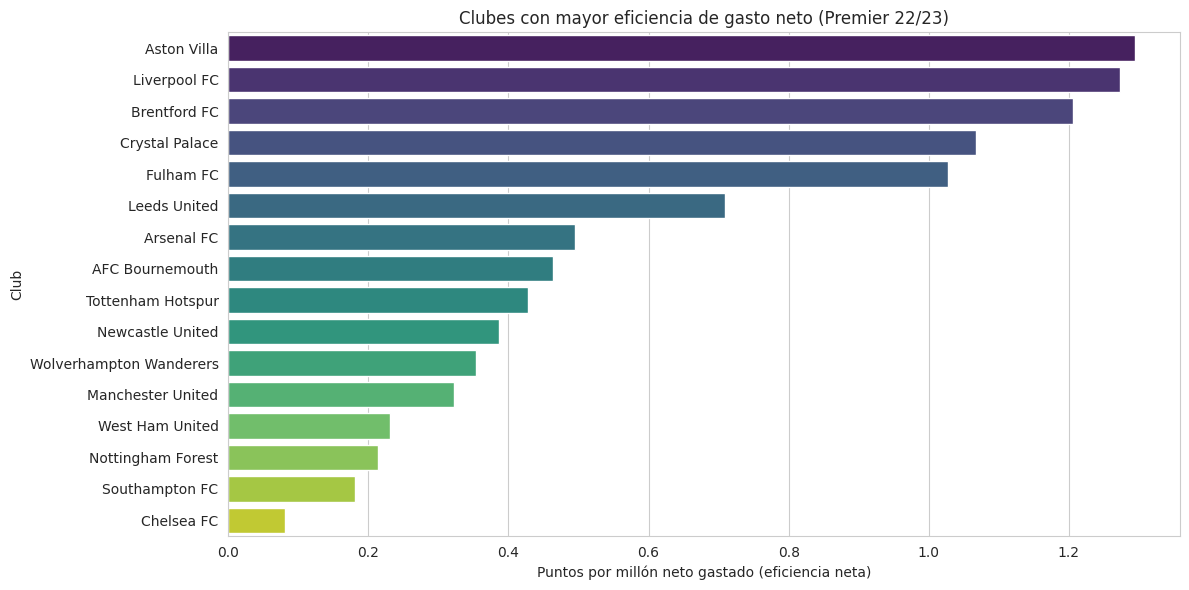

In [11]:
# Gráfico 2 - Barras horizontales de eficiencia neta
#se excluyen los clubes que tuvieron gasto neto NEGATIVO

plt.figure(figsize=(12,6))
top16 = union.nlargest(16, 'eficiencia_neta')
sns.barplot(x='eficiencia_neta', y='club', data=top16, palette='viridis')
plt.xlabel('Puntos por millón neto gastado (eficiencia neta)')
plt.ylabel('Club')
plt.title('Clubes con mayor eficiencia de gasto neto (Premier 22/23)')
plt.tight_layout()
plt.savefig('grafico2_eficiencia_neta.png')
plt.show()

este de abajo OPCIONAL.

**Eficiencia neta**: Se calcula como puntos obtenidos por millón de gasto neto (Pts / (gasto_neto_M + 1)). Se muestra con barras azul celeste.
- Qué nos indica: Una mayor eficiencia neta indica que un club es muy eficaz a la hora de convertir su saldo total del mercado de fichajes en rendimiento en el terreno de juego (puntos).
- Los clubes con gasto neto cero o negativo (es decir, que obtuvieron beneficios) pueden parecer extremadamente eficientes en este indicador, ya que ganan puntos sin un desembolso financiero neto

**Eficiencia bruta**: Se calcula como puntos obtenidos por millón de gasto total (Pts / (gasto_total_in_M + 1)), sin tener en cuenta los ingresos por ventas.(No tiene en cuenta el dinero recibido por la venta de jugadores.) Se muestra con barras color salmón.

La eficiencia bruta se centra exclusivamente en el poder adquisitivo y en cómo esa inversión directa en nuevos talentos se traduce en puntos.
- Una mayor eficiencia bruta sugiere que un club utiliza de forma muy eficaz el dinero que destina a la compra de jugadores, independientemente de los ingresos por su venta. Esta métrica es útil para comprender el impacto del gasto en adquisiciones de forma aislada.

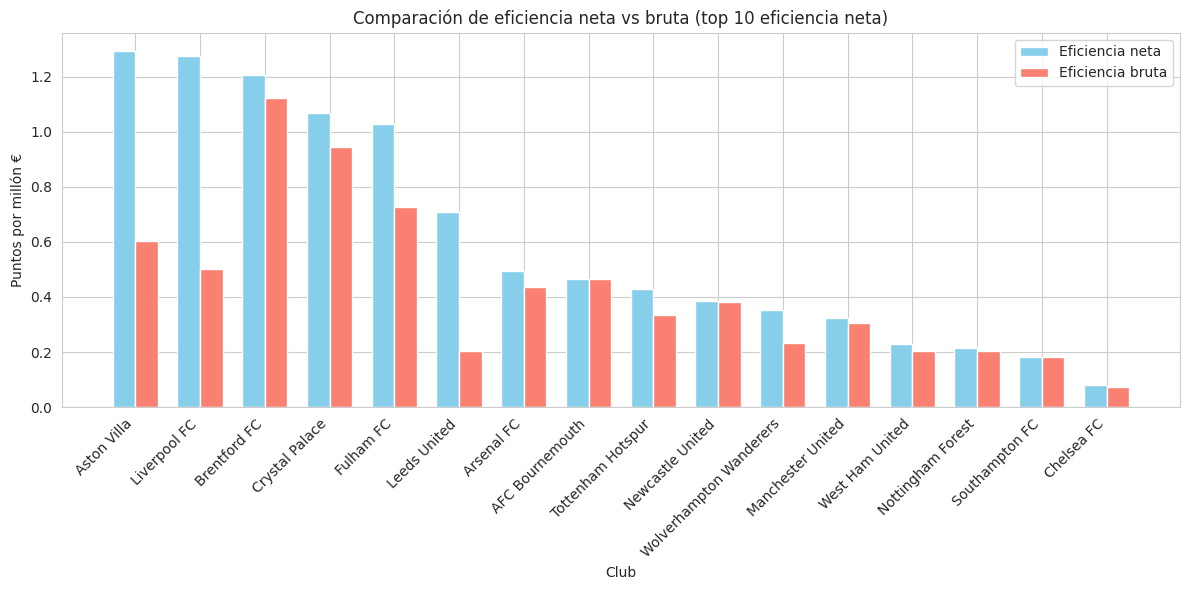

In [12]:
# Celda 10: Gráfico 3 - Comparación eficiencia bruta vs neta (para los mismos que tenian gasto neto positivo en neta)
import matplotlib.pyplot as plt
import numpy as np


top20 = union.nlargest(16, 'eficiencia_neta')

top20_clubs = top20['club'].values
top20_bruta = union[union['club'].isin(top20_clubs)][['club', 'eficiencia_bruta']].set_index('club').loc[top20_clubs]
top20_neta = top20.set_index('club')['eficiencia_neta']

x = np.arange(len(top20_clubs))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))
rects1 = ax.bar(x - width/2, top20_neta, width, label='Eficiencia neta', color='skyblue')
rects2 = ax.bar(x + width/2, top20_bruta['eficiencia_bruta'], width, label='Eficiencia bruta', color='salmon')
ax.set_ylabel('Puntos por millón €')
ax.set_xlabel('Club')
ax.set_title('Comparación de eficiencia neta vs bruta (top 10 eficiencia neta)')
ax.set_xticks(x)
ax.set_xticklabels(top20_clubs, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('grafico3_comparacion_eficiencias.png')
plt.show()

(PROBANDO OTROS GRAFICQUITOS)

In [13]:
# Cargar posiciones 21/22 y unir con 22/23
pos21 = pd.read_csv('premier posiciones 21_22 - Sheet1.csv')  # ajusta nombre
pos21['club'] = pos21['Equipo']
pos21 = pos21[['club', 'Pts']].rename(columns={'Pts': 'pts_2122'})

# Unir con el DataFrame 'union' que ya tiene pts_2223 y gasto neto
union = pd.merge(union, pos21, on='club', how='left')
union['delta_pts'] = union['Pts'] - union['pts_2122']

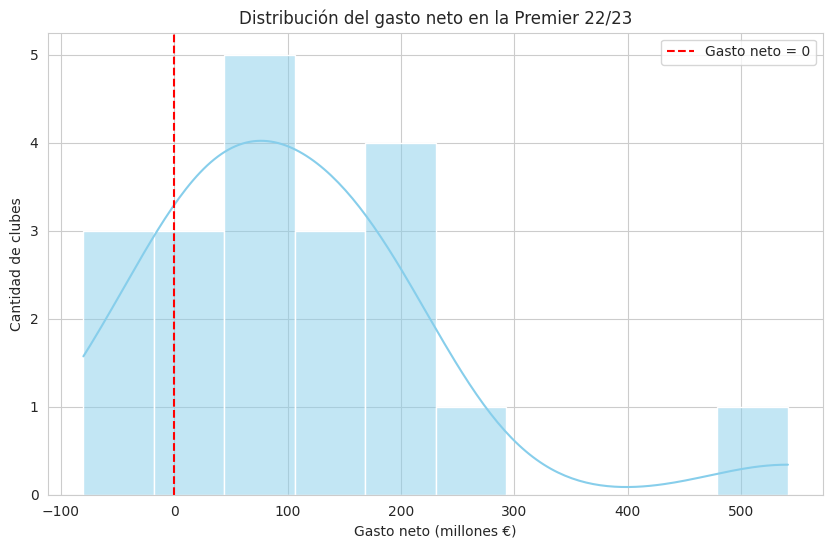

In [14]:
# Gráfico B: histograma de gasto neto
plt.figure(figsize=(10,6))
sns.histplot(union['gasto_neto_M'], bins=10, kde=True, color='skyblue')
plt.xlabel('Gasto neto (millones €)')
plt.ylabel('Cantidad de clubes')
plt.title('Distribución del gasto neto en la Premier 22/23')
plt.axvline(x=0, color='red', linestyle='--', label='Gasto neto = 0')
plt.legend()
plt.savefig('graficoB_histograma_gasto.png')
plt.show()

In [15]:
# =============================================
# OTRO Gráfico para hacer: Relación entre posición 21/22 y 22/23 (dispersión)
# Tipo: relación entre dos variables (c)
# =============================================
# Unir posiciones de ambas temporadas

/tmp/ipykernel_572/1363616888.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ascendido', y='gasto_promedio_M', data=gasto_bruto_asc, palette=['skyblue', 'orange'])


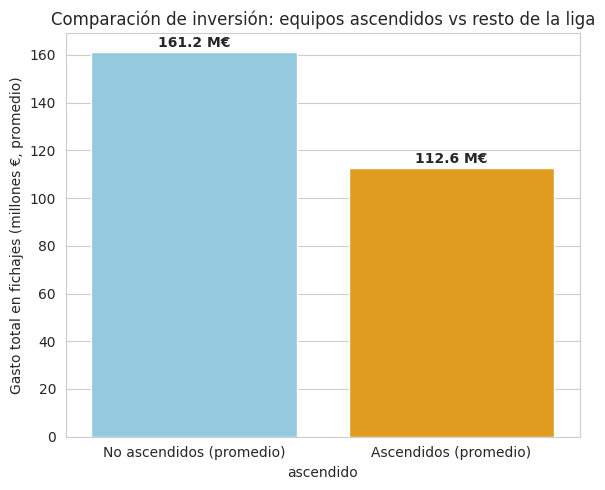

In [16]:
# =============================================
# Gráfico 2: Inversión de ascendidos vs resto (barras)
# Tipo: comparación entre categorías (b)
# =============================================
# Identificar ascendidos (equipos que no estaban en 21/22)
# Según tu dataset 21/22, los que no aparecen: Bournemouth, Fulham, Nottingham Forest (ascendieron)
ascendidos = ['AFC Bournemouth', 'Fulham FC', 'Nottingham Forest']
union['es_ascendido'] = union['club'].isin(ascendidos)

# Calcular gasto total bruto (in) por club
gasto_bruto_asc = union.groupby('es_ascendido')['gasto_total_in_M'].mean().reset_index()
gasto_bruto_asc.columns = ['ascendido', 'gasto_promedio_M']

plt.figure(figsize=(6,5))
sns.barplot(x='ascendido', y='gasto_promedio_M', data=gasto_bruto_asc, palette=['skyblue', 'orange'])
plt.xticks([0,1], ['No ascendidos (promedio)', 'Ascendidos (promedio)'])
plt.ylabel('Gasto total en fichajes (millones €, promedio)')
plt.title('Comparación de inversión: equipos ascendidos vs resto de la liga')
# Agregar valor encima de las barras
for i, val in enumerate(gasto_bruto_asc['gasto_promedio_M']):
    plt.text(i, val + 2, f'{val:.1f} M€', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_intermedio_2_ascendidos_vs_resto.png')
plt.show()

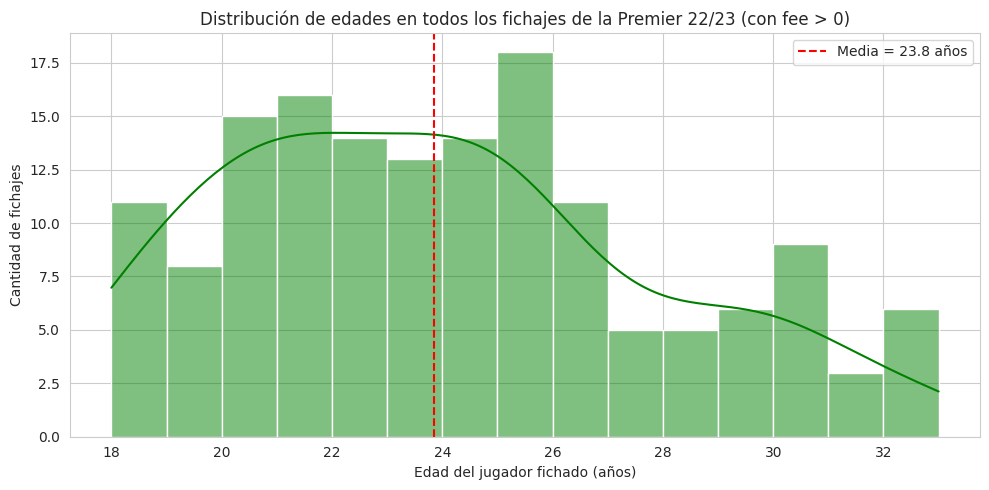

In [17]:
# =============================================
# Gráfico 3: Edad promedio de los fichajes por club (boxplot o histograma)
# Tipo: distribución (a) - usamos boxplot para comparar distribuciones entre clubes
# =============================================
# Calcular edad promedio de los fichajes IN (excluyendo end of loan y sin fee)
transfers_in = transfers[transfers['transfer_movement'] == 'in'].copy()
# Filtrar solo transferencias con fee > 0 (para evitar préstamos sin costo y retornos)
transfers_in = transfers_in[transfers_in['fee_cleaned'] > 0]
# Calcular edad media por club
edad_media = transfers_in.groupby('club_name')['age'].mean().reset_index()
edad_media.columns = ['club', 'edad_promedio_fichajes']

# Unir con union para tener solo los de Premier
edad_media_premier = pd.merge(union[['club']], edad_media, on='club', how='inner')

# Opción: boxplot de la distribución de edades entre clubes (no tiene mucho sentido porque cada club da un valor)
# Mejor: histograma de edades de todos los fichajes (para ver la distribución general)
plt.figure(figsize=(10,5))
sns.histplot(transfers_in['age'], bins=15, kde=True, color='green')
plt.xlabel('Edad del jugador fichado (años)')
plt.ylabel('Cantidad de fichajes')
plt.title('Distribución de edades en todos los fichajes de la Premier 22/23 (con fee > 0)')
plt.axvline(x=transfers_in['age'].mean(), color='red', linestyle='--', label=f'Media = {transfers_in["age"].mean():.1f} años')
plt.legend()
plt.tight_layout()
plt.savefig('grafico_intermedio_3_distribucion_edades.png')
plt.show()

## Eficiencia de Gasto: Puntos por Millón de Euro Neto (plasma lo mismo q el hecho antes)

In [18]:
union['pts_por_millon_neto'] = union['Pts'] / union['gasto_neto_M']

# Manejar casos donde gasto_neto_M es 0 o negativo (ingresos > gastos)
# Para gasto neto = 0, pts_por_millon_neto debería ser infinito (o un valor muy alto)
# Para gasto neto negativo, la interpretación 'por millón' se complica, podríamos visualizarlo de otra forma o categorizar.
# Por ahora, vamos a reemplazar inf con 0 para evitar errores en el gráfico, pero hay que tenerlo en cuenta para la interpretación.
union['pts_por_millon_neto'] = union['pts_por_millon_neto'].replace([np.inf, -np.inf], np.nan)

# Para los equipos con gasto neto <= 0, vamos a asignarles un valor que indique muy alta eficiencia
# o simplemente categorizarlos de forma separada si el gasto neto es 0 o negativo.
# Para este gráfico, filtraremos los valores negativos y NaN para mantener la interpretación directa de 'puntos por millón gastado'
eficiencia_positiva = union[union['gasto_neto_M'] > 0].copy()

# Ordenar por eficiencia
eficiencia_positiva = eficiencia_positiva.sort_values('pts_por_millon_neto', ascending=False)

print("Eficiencia de gasto (Puntos por millón de Euro Neto) para clubes con gasto neto positivo:")
display(eficiencia_positiva[['club', 'Pts', 'gasto_neto_M', 'pts_por_millon_neto']].head(10))

Eficiencia de gasto (Puntos por millón de Euro Neto) para clubes con gasto neto positivo:


,club,Pts,gasto_neto_M,pts_por_millon_neto
6,Aston Villa,61,46.14,1.322063
4,Liverpool FC,67,51.60,1.298450
8,Brentford FC,59,47.90,1.231733
10,Crystal Palace,45,41.14,1.093826
9,Fulham FC,52,49.60,1.048387
18,Leeds United,31,42.69,0.726165
1,Arsenal FC,84,168.56,0.498339
14,AFC Bournemouth,39,83.10,0.469314
7,Tottenham Hotspur,60,139.15,0.431189
3,Newcastle United,71,183.04,0.387893


/tmp/ipykernel_572/906110228.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pts_por_millon_neto', y='club', data=eficiencia_positiva, palette='viridis')


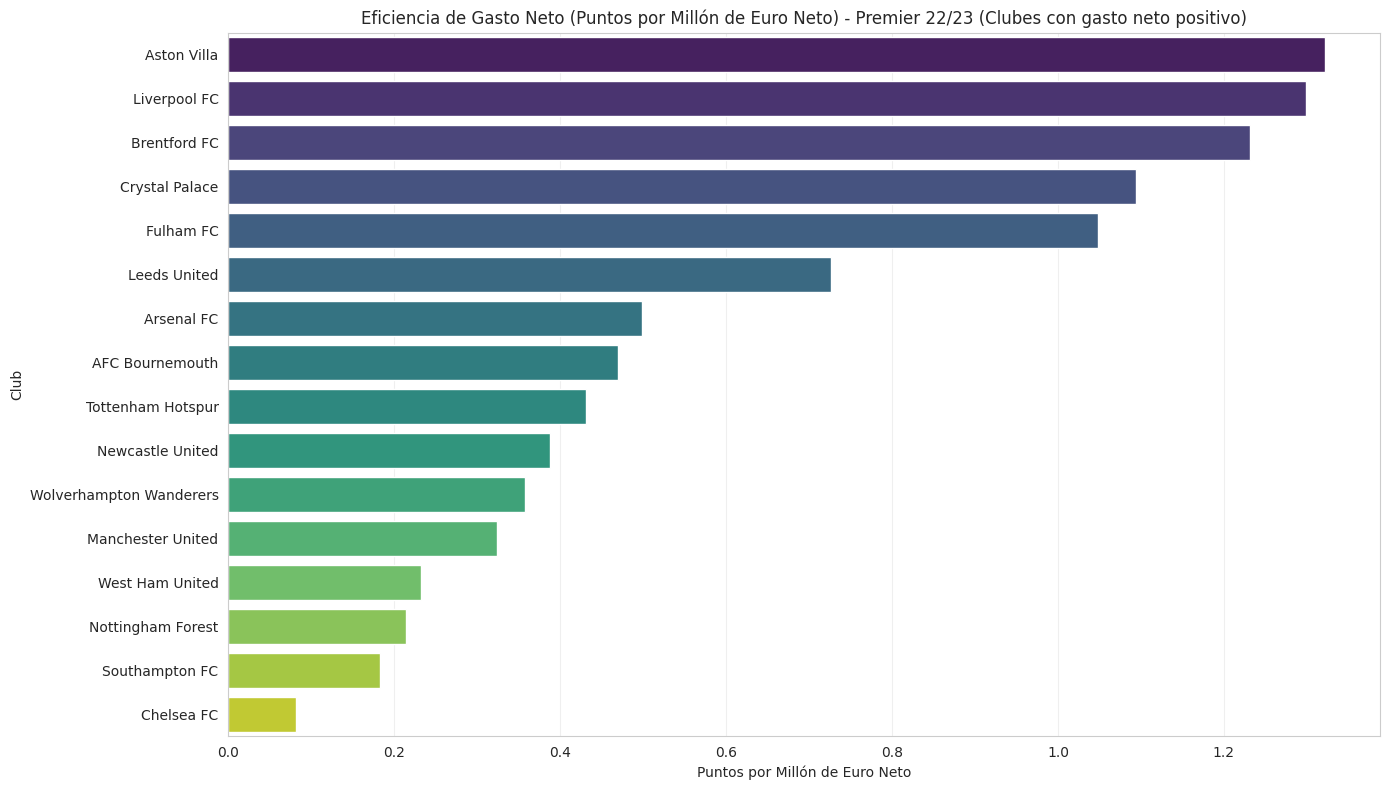

In [19]:
plt.figure(figsize=(14, 8))
sns.barplot(x='pts_por_millon_neto', y='club', data=eficiencia_positiva, palette='viridis')
plt.xlabel('Puntos por Millón de Euro Neto')
plt.ylabel('Club')
plt.title('Eficiencia de Gasto Neto (Puntos por Millón de Euro Neto) - Premier 22/23 (Clubes con gasto neto positivo)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('grafico3_eficiencia_gasto_neto.png')
plt.show()

El gráfico anterior muestra la eficiencia de los clubes con gasto neto positivo, es decir, que gastaron más de lo que ingresaron por transferencias. Un valor más alto de 'Puntos por Millón de Euro Neto' indica una mayor eficiencia. Podemos observar qué clubes lograron obtener una buena cantidad de puntos por cada millón de euros invertido en el mercado de transferencias.

Ahora, consideremos los clubes con gasto neto cero o negativo (aquellos que vendieron más de lo que compraron o tuvieron un gasto muy bajo), que el gráfico anterior excluyó. Estos clubes son inherentemente muy eficientes desde una perspectiva de gasto neto, ya que generaron rendimiento deportivo sin una inversión neta de capital en transferencias, o incluso obteniendo ganancias.

In [20]:
eficiencia_no_positiva = union[union['gasto_neto_M'] <= 0].copy()

# Ordenar por gasto_neto_M (los más negativos - que más ganaron - primero)
eficiencia_no_positiva = eficiencia_no_positiva.sort_values('gasto_neto_M', ascending=True)

print("Clubes con gasto neto cero o negativo (ingresos >= gastos):")
display(eficiencia_no_positiva[['club', 'Pts', 'gasto_neto_M']])


Clubes con gasto neto cero o negativo (ingresos >= gastos):


,club,Pts,gasto_neto_M
5,Brighton & Hove Albion,62,-80.1
17,Leicester City,34,-33.4
16,Everton FC,36,-18.4
0,Manchester City,89,-11.7


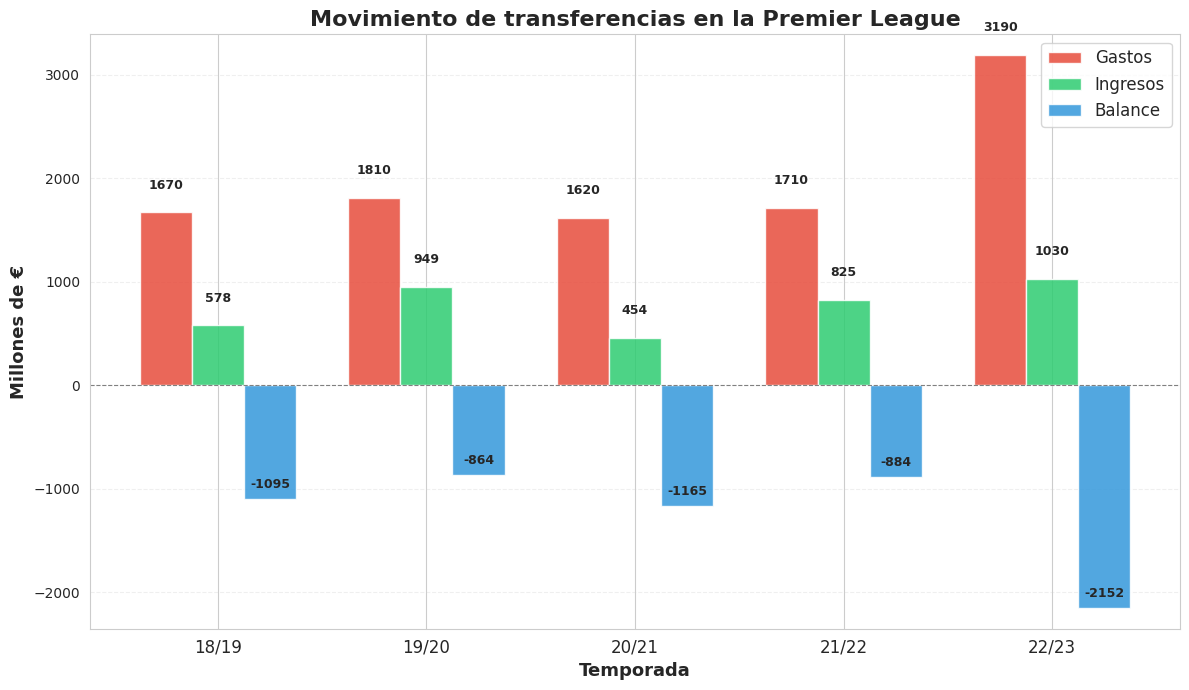

📊 Resumen por temporada:
Temp.    Gastos (M€)    Ingresos (M€)    Balance (M€)
-------------------------------------------------------
18/19    1,670          577.52           -1,095.29
19/20    1,810          949.47           -864.47
20/21    1,620          453.96           -1,164.84
21/22    1,710          825.09           -884.16
22/23    3,190          1,030.00         -2,151.51


In [21]:
# %% [markdown]
# # 📊 Transferencias en la Premier League (2018-2023)
# Gráfico de gastos, ingresos y balance por temporada

#PUESTAS A MANO LOS DATOS PORQ ERAN POCOS

# Temporadas
temporadas = ['18/19', '19/20', '20/21', '21/22', '22/23']

# Datos en millones de €
gastos  = [1670, 1810, 1620, 1710, 3190]    # mil mill. → millones
ingresos = [577.52, 949.47, 453.96, 825.09, 1030]
balance = [-1095.29, -864.47, -1164.84, -884.16, -2151.51]

# %%
# Configuración del gráfico
x = np.arange(len(temporadas))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 7))

# Barras
bars1 = ax.bar(x - width, gastos, width, label='Gastos', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x, ingresos, width, label='Ingresos', color='#2ecc71', alpha=0.85)
bars3 = ax.bar(x + width, balance, width, label='Balance', color='#3498db', alpha=0.85)

# Línea de referencia en cero para el balance
ax.axhline(y=0, color='gray', linewidth=0.8, linestyle='--')

# Etiquetas y títulos
ax.set_xlabel('Temporada', fontsize=13, fontweight='bold')
ax.set_ylabel('Millones de €', fontsize=13, fontweight='bold')
ax.set_title('Movimiento de transferencias en la Premier League', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(temporadas, fontsize=12)
ax.legend(fontsize=12)

# Agregar valores sobre las barras
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        va = 'bottom' if height >= 0 else 'top'
        offset = 15 if height >= 0 else -15
        ax.annotate(f'{height:.0f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, offset if height >= 0 else -offset),
                    textcoords="offset points",
                    ha='center', va=va, fontsize=9, fontweight='bold')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

# Ajustar límites del eje Y para dejar espacio a las etiquetas
y_min = min(balance) - 200
y_max = max(gastos) + 200
ax.set_ylim(y_min, y_max)

# Grid en Y
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# %%
print("📊 Resumen por temporada:")
print(f"{'Temp.':<8} {'Gastos (M€)':<14} {'Ingresos (M€)':<16} {'Balance (M€)'}")
print("-" * 55)
for i, t in enumerate(temporadas):
    print(f"{t:<8} {gastos[i]:<14,.0f} {ingresos[i]:<16,.2f} {balance[i]:,.2f}")

In [23]:
promedio_campeon = 38
promedio_europa = 59
promedio_salvacion = 91

In [24]:
# Celda: Función de costo por punto y análisis por categorías

# 1. Definimos la función matemática requerida (con su docstring)
def calcular_costo_por_punto(gasto_neto, puntos):
    """
    Calcula el costo financiero (en millones) por cada punto obtenido en la liga.

    Parámetros:
    gasto_neto (float): La diferencia entre compras y ventas en millones de euros.
    puntos (int o float): Cantidad de puntos obtenidos en la temporada.

    Retorna:
    float: El costo por punto. Si el gasto es negativo (el club generó ganancias)
           y los puntos son > 0, el valor será negativo, indicando máxima eficiencia.
           Retorna 0 si los puntos son 0 para evitar errores matemáticos.
    """
    if puntos == 0:
        return 0
    return gasto_neto / puntos

# Definir umbrales de puntos para categorización (pueden ajustarse según el análisis previo)
promedio_campeon = 80  # Ejemplo: Puntos para ser considerado nivel campeón
promedio_europa = 60   # Ejemplo: Puntos para clasificación europea
promedio_salvacion = 35 # Ejemplo: Puntos para asegurar la salvación

def categorizar_objetivo(puntos):
    """
    Clasifica a un equipo en una categoría según los umbrales promedio calculados.
    """
    if puntos >= promedio_campeon:
        return '1. Nivel Campeón'
    elif puntos >= promedio_europa:
        return '2. Clasificación Europea'
    elif puntos >= promedio_salvacion:
        return '3. Salvación'
    else:
        return '4. Zona de Descenso'

# 2. Aplicamos las funciones a nuestro DataFrame
# Nota: Ajusta 'gasto_neto_M' y 'Pts' (o 'puntos') a los nombres exactos de las columnas de tu compañero
union['costo_por_punto'] = union.apply(lambda row: calcular_costo_por_punto(row['gasto_neto_M'], row['puntos']), axis=1)

union['categoria_objetivo'] = union['puntos'].apply(categorizar_objetivo)

# 3. Agrupamos para ver el promedio de gasto y costo por punto en cada categoría
resumen_objetivos = union.groupby('categoria_objetivo').agg(
    equipos_en_categoria=('club', 'count'),
    gasto_neto_promedio_M=('gasto_neto_M', 'mean'),
    puntos_promedio=('puntos', 'mean'),
    costo_por_punto_promedio=('costo_por_punto', 'mean')
).round(2)

# Mostramos la tabla resultante
print("--- ANÁLISIS DE COSTO POR PUNTO SEGÚN OBJETIVO ALCANZADO ---")
display(resumen_objetivos)

--- ANÁLISIS DE COSTO POR PUNTO SEGÚN OBJETIVO ALCANZADO ---


,equipos_en_categoria,gasto_neto_promedio_M,puntos_promedio,costo_por_punto_promedio
categoria_objetivo,,,,
1. Nivel Campeón,2,78.43,86.50,0.94
2. Clasificación Europea,6,95.27,66.00,1.37
3. Salvación,9,134.35,43.78,3.15
4. Zona de Descenso,3,48.65,30.00,1.95
